Problem 1

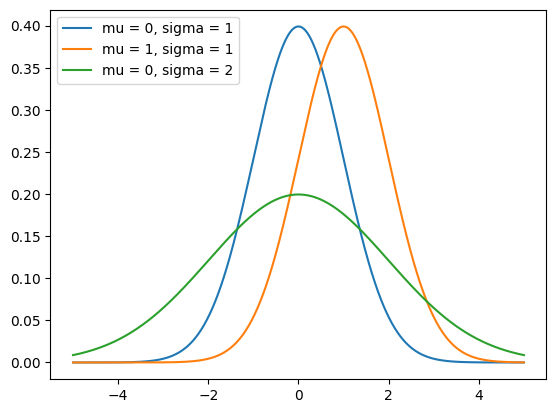

<Figure size 640x480 with 0 Axes>

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as integrate
import random

def Gaussian(x, mu, sigma):
    return (1.0/(sigma*np.sqrt(2*np.pi)))*np.exp(-(x-mu)**2/(2*sigma**2))

# Problem 1
x = np.linspace(-5,5,1000)
f1 = Gaussian(x,0.0,1.0)
f2 = Gaussian(x,1.0,1.0)
f3 = Gaussian(x,0.0,2.0)

plt.plot(x, f1, label = "mu = 0, sigma = 1")
plt.plot(x, f2, label = "mu = 1, sigma = 1")
plt.plot(x, f3, label = "mu = 0, sigma = 2")
plt.legend(loc="upper left")

plt.savefig('E1_Problem_1.pdf')
plt.show()
plt.clf()

print("Probability to produce the new particle with a mass of 205 GeV or more is " + str(round(100*(integrate.quad(lambda x: Gaussian(x,200.0, 2.0), 205.0, +np.inf))[0],2)) + "%.")
#print("Probability to produce the new particle with a mass with mass between 199 and 201 GeV " + str(100*(integrate.quad(lambda x: Gaussian(x,200.0, 2.0), 199.0, 201.0))[0]) + "%.")
print("Probability to produce the two particles with masses above 203 GeV is " + str(round(100*(integrate.quad(lambda x: Gaussian(x,200.0, 2.0), 203.0, +np.inf))[0]**2,2)) + "%.")

Problem 2

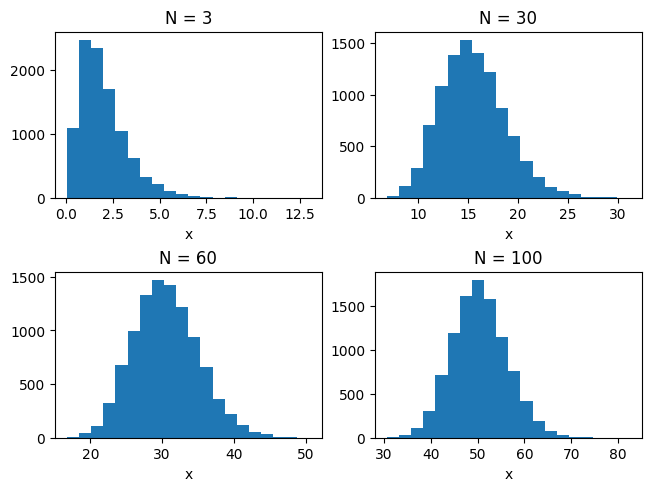

<Figure size 640x480 with 0 Axes>

In [3]:
# Problem 2
x_histo_3 = []
x_histo_30 = []
x_histo_60 = []
x_histo_100 = []

for i in range(10000):
    x = 0.0
    N = 3
    for j in range(N):
        x = x + np.random.exponential(scale= j + 1.0, size=None)
    x_histo_3.append(x/N)

    x = 0.0
    N = 30
    for j in range(N):
        x = x + np.random.exponential(scale= j + 1.0, size=None)
    x_histo_30.append(x/N)

    x = 0.0
    N = 60
    for j in range(N):
        x = x + np.random.exponential(scale= j + 1.0, size=None)
    x_histo_60.append(x/N)

    x = 0.0
    N = 100
    for j in range(N):
        x = x + np.random.exponential(scale= j + 1.0, size=None)
    x_histo_100.append(x/N)

# Initialise the subplot function using number of rows and columns
figure, axis = plt.subplots(2, 2, constrained_layout=True)

axis[0, 0].hist(x_histo_3, bins=20)
axis[0, 0].set_title("N = 3")
axis[0, 0].set_xlabel("x")

axis[0, 1].hist(x_histo_30, bins=20)
axis[0, 1].set_title("N = 30")
axis[0, 1].set_xlabel("x")

axis[1, 0].hist(x_histo_60, bins=20)
axis[1, 0].set_title("N = 60")
axis[1, 0].set_xlabel("x")

axis[1, 1].hist(x_histo_100, bins=20)
axis[1, 1].set_title("N = 100")
axis[1, 1].set_xlabel("x")

plt.savefig('E1_Problem_2.pdf')
plt.show()
plt.clf()

Problems 3 and 4

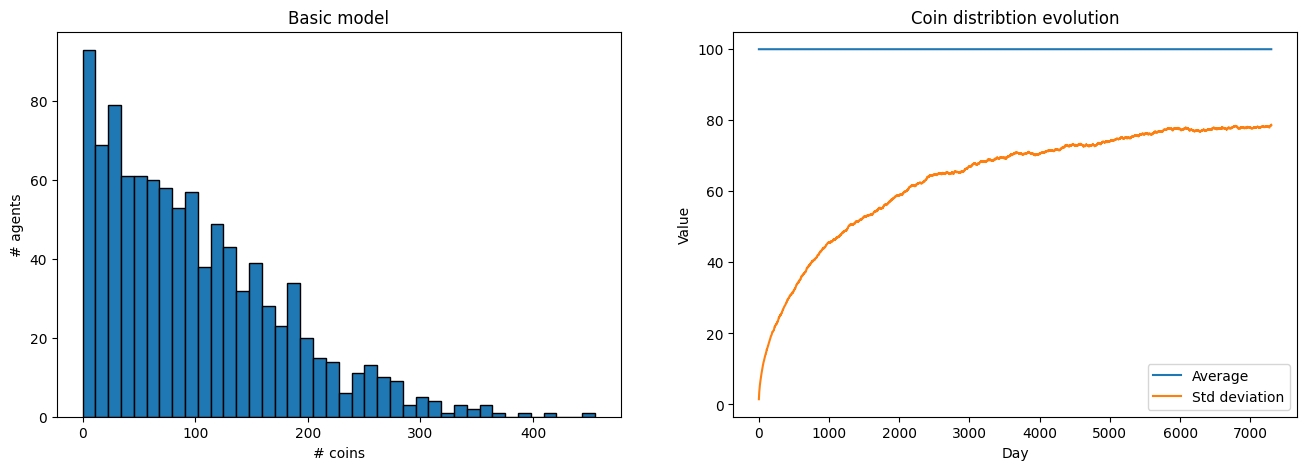

Minimum amount of money = 0
Maximum amount of money = 455
Std deviation = 78.68278083545344


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------
# 1) BASIC MODEL - simulation function
# -----------------------------------------------

def simulate_economy(n_agents=1000, starting_money=100, n_days=2000, seed=None):

    if seed is not None:
        np.random.seed(seed)

    # Create array to store state of income
    money = np.full(n_agents, starting_money, dtype=int)

    averages = []
    st_deviations = []

    for day in range(n_days):
        # random partnering
        partners = np.random.randint(0, n_agents, n_agents)

        for i in range(n_agents):
            j = partners[i]
            if i == j:
                continue  # can't choose yourself

            # coin toss
            winner = i if np.random.rand() < 0.5 else j
            looser = j if winner == i else i

            # can't go in dept
            if money[looser] > 0:
                money[looser] -= 1
                money[winner] += 1

        averages.append(np.mean(money))
        st_deviations.append(np.std(money))

    return money, np.array(averages), np.array(st_deviations)


# -----------------------------------------------------
# 2) PLOTTING FUNCTION
# -----------------------------------------------------

def plot_results(money, averages, st_deviations, title="Wealth distribution"):
    plt.figure(figsize=(16,5))

    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(money, bins=40, edgecolor='black')
    plt.title(title)
    plt.xlabel("# coins")
    plt.ylabel("# agents")

    # Average and st_dev evolution
    plt.subplot(1, 2, 2)
    plt.plot(averages, label="Average")
    plt.plot(st_deviations, label="Std deviation")
    plt.title("Coin distribtion evolution")
    plt.xlabel("Day")
    plt.ylabel("Value")
    plt.legend()

    plt.show()
# -----------------------------------------------------
# 3) RUNNING THE SIMULATION
# -----------------------------------------------------

money, averages, st_deviations = simulate_economy(
    n_agents=1000,
    starting_money=100,
    n_days=7300,
    seed=42
)

plot_results(money, averages, st_deviations,
                  title="Basic model")

print("Minimum amount of money =", np.min(money))
print("Maximum amount of money =", np.max(money))
print("Std deviation =", np.std(money))

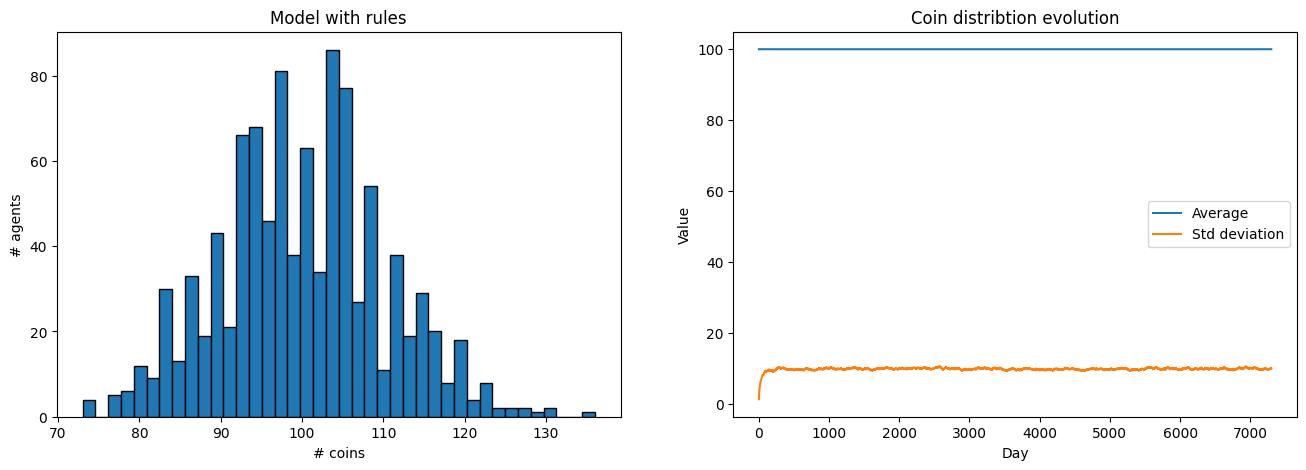

Minimum amount of money = 73
Maximum amount of money = 136
Std deviation = 10.115137171585959


In [14]:
# -----------------------------------------------
# MODEL WITH RULES where your starting wealth affects the probability to win
# -----------------------------------------------

def simulate_economy_withrules(n_agents=1000, starting_money=100, n_days=2000, seed=None):

    if seed is not None:
        np.random.seed(seed)

    # Create array to store state of income
    money = np.full(n_agents, starting_money, dtype=int)

    averages = []
    st_deviations = []

    for day in range(n_days):
        # random partnering
        partners = np.random.randint(0, n_agents, n_agents)

        for i in range(n_agents):
            j = partners[i]
            if i == j:
                continue  # can't choose yourself

            # coin toss
            random_number = np.random.randint(0, money[i]+money[j], 1)[0]
            winner = i if random_number < money[j] else j
            looser = j if winner == i else i


            # can't go in dept
            if money[looser] > 0:
                money[looser] -= 1
                money[winner] += 1

        averages.append(np.mean(money))
        st_deviations.append(np.std(money))

    return money, np.array(averages), np.array(st_deviations)


money, averages, st_deviations = simulate_economy_withrules(
    n_agents=1000,
    starting_money=100,
    n_days=7300,
    seed=42
)

plot_results(money, averages, st_deviations,
                  title="Model with rules")

print("Minimum amount of money =", np.min(money))
print("Maximum amount of money =", np.max(money))
print("Std deviation =", np.std(money))